Lección 5: Machine Learning escalable con MLlib

In [10]:
#link github https://github.com/lucasalechilet/Curso_FCD/blob/main/L5_MLlib_Escalable.ipynb
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, IntegerType, FloatType
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# fijamos la semilla para reproducibilidad
np.random.seed(42)

# iniciamos la sesión de Spark con configuración local
# en un entorno distribuido real, esta configuración vendría del cluster manager
spark = SparkSession.builder \
    .appName('ecommerce_purchase_prediction') \
    .master('local[*]') \
    .config('spark.driver.memory', '2g') \
    .getOrCreate()

# silenciamos los logs de INFO para que la salida sea más limpia
spark.sparkContext.setLogLevel('WARN')

print('SparkSession iniciada correctamente')
print('Versión de Spark:', spark.version)


SparkSession iniciada correctamente
Versión de Spark: 4.0.2


Iniciamos la sesión de Spark con `local[*]` para que use todos los núcleos disponibles en el entorno local. En producción esto se reemplazaría por la URL del cluster (por ejemplo `spark://master:7077`) y la configuración de memoria y ejecutores dependería de los recursos disponibles.

In [11]:
def generar_datos_ecommerce(n=50000, seed=42):
    # generamos un dataset sintético de comportamiento de clientes de e-commerce
    # las variables reflejan el tipo de datos que describe el caso:
    # navegación, historial de compras y calificaciones de productos
    rng = np.random.default_rng(seed)

    # features de navegación
    paginas_visitadas = rng.integers(1, 50, size=n)
    tiempo_sesion_min = rng.uniform(0.5, 120, size=n).round(1)
    dias_desde_ultima_visita = rng.integers(0, 90, size=n)

    # features de historial de compras
    compras_ultimos_30_dias = rng.integers(0, 10, size=n)
    monto_promedio_compra = rng.uniform(500, 50000, size=n).round(0)
    items_en_carrito = rng.integers(0, 20, size=n)

    # features de calificaciones y engagement
    calificacion_promedio_dada = rng.uniform(1, 5, size=n).round(1)
    productos_en_wishlist = rng.integers(0, 30, size=n)
    clicks_en_recomendaciones = rng.integers(0, 15, size=n)

    # generamos el target: compra en los próximos días (1=sí, 0=no)
    # la probabilidad de compra está correlacionada con los features para que el modelo aprenda
    prob_compra = (
        0.10
        + 0.015 * (items_en_carrito > 0).astype(float)
        + 0.020 * (compras_ultimos_30_dias > 0).astype(float)
        + 0.010 * (productos_en_wishlist > 5).astype(float)
        + 0.008 * (tiempo_sesion_min > 15).astype(float)
        + 0.005 * (clicks_en_recomendaciones > 3).astype(float)
        - 0.005 * (dias_desde_ultima_visita > 30).astype(float)
    ).clip(0.05, 0.85)
    compra_target = rng.binomial(1, prob_compra)

    # construimos el DataFrame de pandas y luego lo convertimos a Spark
    df_pandas = pd.DataFrame({
        'paginas_visitadas': paginas_visitadas,
        'tiempo_sesion_min': tiempo_sesion_min,
        'dias_desde_ultima_visita': dias_desde_ultima_visita,
        'compras_ultimos_30_dias': compras_ultimos_30_dias,
        'monto_promedio_compra': monto_promedio_compra,
        'items_en_carrito': items_en_carrito,
        'calificacion_promedio_dada': calificacion_promedio_dada,
        'productos_en_wishlist': productos_en_wishlist,
        'clicks_en_recomendaciones': clicks_en_recomendaciones,
        'label': compra_target.astype(int)
    })

    # convertimos a Spark DataFrame: en producción esto vendría de un read.parquet() desde HDFS
    df_spark = spark.createDataFrame(df_pandas)

    print(f'Dataset generado: {df_spark.count()} registros, {len(df_spark.columns)} columnas')
    print('\nEsquema del DataFrame:')
    df_spark.printSchema()
    print('\nDistribución del target:')
    df_spark.groupBy('label').count().orderBy('label').show()

    return df_spark

df = generar_datos_ecommerce(n=50000)


Dataset generado: 50000 registros, 10 columnas

Esquema del DataFrame:
root
 |-- paginas_visitadas: long (nullable = true)
 |-- tiempo_sesion_min: double (nullable = true)
 |-- dias_desde_ultima_visita: long (nullable = true)
 |-- compras_ultimos_30_dias: long (nullable = true)
 |-- monto_promedio_compra: double (nullable = true)
 |-- items_en_carrito: long (nullable = true)
 |-- calificacion_promedio_dada: double (nullable = true)
 |-- productos_en_wishlist: long (nullable = true)
 |-- clicks_en_recomendaciones: long (nullable = true)
 |-- label: long (nullable = true)


Distribución del target:
+-----+-----+
|label|count|
+-----+-----+
|    0|42684|
|    1| 7316|
+-----+-----+



Generamos un dataset sintético de 50.000 registros que simula el tipo de datos que describe el caso: navegación (páginas visitadas, tiempo de sesión, días desde última visita), historial de compras (compras recientes, monto promedio, carrito) y engagement (calificaciones, wishlist, clicks en recomendaciones).  

El target `label` indica si el cliente realizó una compra en los próximos días (1) o no (0). Para que el modelo tenga algo que aprender, la probabilidad de compra está correlacionada con las variables más relevantes del negocio: tener items en el carrito y compras recientes aumenta la probabilidad, mientras que no haber visitado el sitio en más de 30 días la reduce.  

En producción, este `df_spark` vendría de un `spark.read.parquet()` o `spark.read.csv()` apuntando a una ruta en HDFS o S3, sin necesidad de modificar ninguna de las etapas siguientes del pipeline.

/tmp/ipykernel_1622/4113428350.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1622/4113428350.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1622/4113428350.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


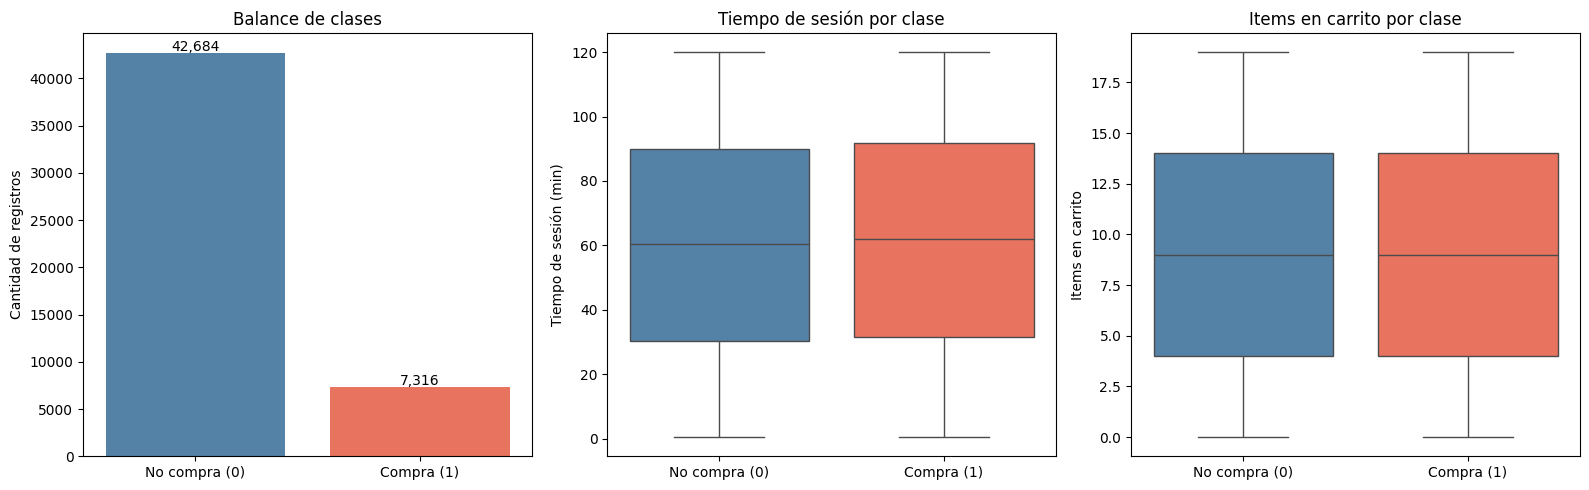

Estadísticas descriptivas (muestra):
       paginas_visitadas  tiempo_sesion_min  dias_desde_ultima_visita  compras_ultimos_30_dias  monto_promedio_compra  items_en_carrito  calificacion_promedio_dada  productos_en_wishlist  clicks_en_recomendaciones     label
count           50000.00           50000.00                  50000.00                 50000.00               50000.00          50000.00                    50000.00               50000.00                    50000.0  50000.00
mean               24.97              60.42                     44.54                     4.49               25257.89              9.45                        3.01                  14.44                        7.0      0.15
std                14.16              34.43                     25.99                     2.87               14310.92              5.77                        1.16                   8.64                        4.3      0.35
min                 1.00               0.50                      0.

In [12]:
def explorar_datos(df):
    # convertimos a pandas solo para las visualizaciones exploratorias
    # en producción con millones de filas se usaría df.sample() antes de toPandas()
    df_pd = df.toPandas()

    # distribución del target
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # gráfico 1: balance de clases
    conteo = df_pd['label'].value_counts()
    sns.barplot(
        x=['No compra (0)', 'Compra (1)'],
        y=conteo.values,
        palette=['steelblue', 'tomato'],
        ax=axes[0]
    )
    axes[0].set_title('Balance de clases')
    axes[0].set_ylabel('Cantidad de registros')
    for i, v in enumerate(conteo.values):
        axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=10)

    # gráfico 2: tiempo de sesión por clase
    # mapeamos label a string para que el palette funcione correctamente con seaborn
    df_plot = df_pd.copy()
    df_plot['label_str'] = df_plot['label'].map({0: 'No compra (0)', 1: 'Compra (1)'})
    sns.boxplot(
        data=df_plot,
        x='label_str',
        y='tiempo_sesion_min',
        palette={'No compra (0)': 'steelblue', 'Compra (1)': 'tomato'},
        ax=axes[1]
    )
    axes[1].set_title('Tiempo de sesión por clase')
    axes[1].set_xlabel('')
    axes[1].set_ylabel('Tiempo de sesión (min)')
    # gráfico 3: items en carrito por clase
    sns.boxplot(
        data=df_plot,
        x='label_str',
        y='items_en_carrito',
        palette={'No compra (0)': 'steelblue', 'Compra (1)': 'tomato'},
        ax=axes[2]
    )
    axes[2].set_title('Items en carrito por clase')
    axes[2].set_xlabel('')
    axes[2].set_ylabel('Items en carrito')
    plt.tight_layout()
    plt.show()

    # estadísticas descriptivas
    print('Estadísticas descriptivas (muestra):')
    print(df_pd.describe().round(2).to_string())

    return df_pd

df_pd = explorar_datos(df)


El análisis exploratorio permite verificar el balance de clases antes de entrenar el modelo. Si el dataset estuviera muy desbalanceado (por ejemplo 95% no compra vs 5% compra) habría que aplicar técnicas como oversampling o ajuste de pesos en el clasificador para evitar que el modelo simplemente prediga siempre la clase mayoritaria.  

Los boxplots permiten ver rápidamente qué variables tienen distribuciones distintas entre clases, lo que da una idea preliminar de su poder discriminante antes de construir el modelo.

In [13]:
def preparar_pipeline(feature_cols):
    # VectorAssembler combina todas las columnas de features en un único vector
    # esto es obligatorio en MLlib: todos los modelos esperan una columna 'features' de tipo Vector
    assembler = VectorAssembler(
        inputCols=feature_cols,
        outputCol='features_raw'
    )

    # StandardScaler estandariza el vector de features (media=0, std=1)
    # es importante para Random Forest porque mejora la convergencia
    # y es imprescindible si se usara Regresión Logística
    scaler = StandardScaler(
        inputCol='features_raw',
        outputCol='features',
        withMean=True,
        withStd=True
    )

    # elegimos Random Forest porque es más robusto ante features con distintas escalas
    # y tiene mejor desempeño que la Regresión Logística en datos con relaciones no lineales
    # como el comportamiento de compra, que depende de combinaciones de variables
    rf = RandomForestClassifier(
        featuresCol='features',
        labelCol='label',
        seed=42
    )

    # el Pipeline encadena las etapas: assembler → scaler → modelo
    # esto garantiza que las mismas transformaciones se apliquen tanto al train como al test
    # sin riesgo de data leakage
    pipeline = Pipeline(stages=[assembler, scaler, rf])

    print('Pipeline construido con etapas:')
    for i, stage in enumerate(pipeline.getStages()):
        print(f'  {i+1}. {stage.__class__.__name__}')

    return pipeline, rf

# definimos las columnas de features: todas excepto el target
feature_cols = [
    'paginas_visitadas',
    'tiempo_sesion_min',
    'dias_desde_ultima_visita',
    'compras_ultimos_30_dias',
    'monto_promedio_compra',
    'items_en_carrito',
    'calificacion_promedio_dada',
    'productos_en_wishlist',
    'clicks_en_recomendaciones'
]

pipeline, rf = preparar_pipeline(feature_cols)


Pipeline construido con etapas:
  1. VectorAssembler
  2. StandardScaler
  3. RandomForestClassifier


Elegimos Random Forest sobre Regresión Logística porque el comportamiento de compra de un cliente tiene dependencias no lineales: por ejemplo, un cliente con 0 items en el carrito y muchas compras recientes puede tener alta probabilidad de compra, pero ese patrón no se captura bien con una combinación lineal de variables.  

El uso de Pipeline es fundamental en MLlib: garantiza que las transformaciones (ensamblado y escalado) se apliquen de forma consistente tanto al train como al test, evitando data leakage. Si se calculara el StandardScaler sobre el dataset completo antes de dividir, estaríamos filtrando información del test al modelo.

In [14]:
def dividir_y_validar(df, pipeline, rf):
    # dividimos en train (80%) y test (20%) con semilla fija para reproducibilidad
    train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)

    print(f'Registros de entrenamiento: {train_df.count():,}')
    print(f'Registros de prueba: {test_df.count():,}')

    # definimos la grilla de hiperparámetros para la búsqueda
    # numTrees: cantidad de árboles en el bosque
    # maxDepth: profundidad máxima de cada árbol (controla la complejidad del modelo)
    param_grid = ParamGridBuilder() \
        .addGrid(rf.numTrees, [50, 100]) \
        .addGrid(rf.maxDepth, [5, 10]) \
        .build()

    print(f'\nCombinaciones de hiperparámetros a evaluar: {len(param_grid)}')

    # usamos AUC-ROC como métrica de evaluación porque es más robusta que la accuracy
    # ante datasets desbalanceados: evalúa la capacidad discriminante del modelo
    # independientemente del umbral de clasificación elegido
    evaluator_auc = BinaryClassificationEvaluator(
        labelCol='label',
        rawPredictionCol='rawPrediction',
        metricName='areaUnderROC'
    )

    # CrossValidator aplica k-fold cross validation sobre el train set
    # numFolds=3 para reducir el tiempo de cómputo en este ejemplo
    # en producción se usaría numFolds=5
    cross_val = CrossValidator(
        estimator=pipeline,
        estimatorParamMaps=param_grid,
        evaluator=evaluator_auc,
        numFolds=3,
        seed=42
    )

    print('\n Entrenando con validación cruzada (esto puede tardar unos minutos)...')
    cv_model = cross_val.fit(train_df)
    print('Entrenamiento completado')

    # mostramos el AUC promedio por combinación de hiperparámetros
    print('\n AUC promedio por combinación de hiperparámetros:')
    for params, score in zip(param_grid, cv_model.avgMetrics):
        n_trees = params[rf.numTrees]
        depth = params[rf.maxDepth]
        print(f'  numTrees={n_trees}, maxDepth={depth} → AUC={score:.4f}')

    return cv_model, train_df, test_df

cv_model, train_df, test_df = dividir_y_validar(df, pipeline, rf)


Registros de entrenamiento: 40,137
Registros de prueba: 9,863

Combinaciones de hiperparámetros a evaluar: 4

 Entrenando con validación cruzada (esto puede tardar unos minutos)...
Entrenamiento completado

 AUC promedio por combinación de hiperparámetros:
  numTrees=50, maxDepth=5 → AUC=0.5134
  numTrees=50, maxDepth=10 → AUC=0.5114
  numTrees=100, maxDepth=5 → AUC=0.5153
  numTrees=100, maxDepth=10 → AUC=0.5100


Usamos Cross Validation con 3 folds para ajustar los hiperparámetros del modelo. La grilla evalúa 4 combinaciones (2 valores de `numTrees` × 2 valores de `maxDepth`), lo que implica 12 entrenamientos en total (4 combinaciones × 3 folds). En producción con más recursos se ampliaría la grilla.  

La elección de AUC-ROC como métrica de evaluación es deliberada: en un problema de predicción de compra, el dataset suele estar desbalanceado (hay más no-compras que compras). La accuracy en ese contexto puede ser engañosa: un modelo que predice siempre 0 puede tener 85% de accuracy pero ser completamente inútil. El AUC-ROC no depende del umbral de clasificación y mide la capacidad real del modelo para distinguir entre clases.

Métricas de evaluación en test set
AUC-ROC:   0.5095
Accuracy:  0.8521
Precision: 0.7260
Recall:    0.8521


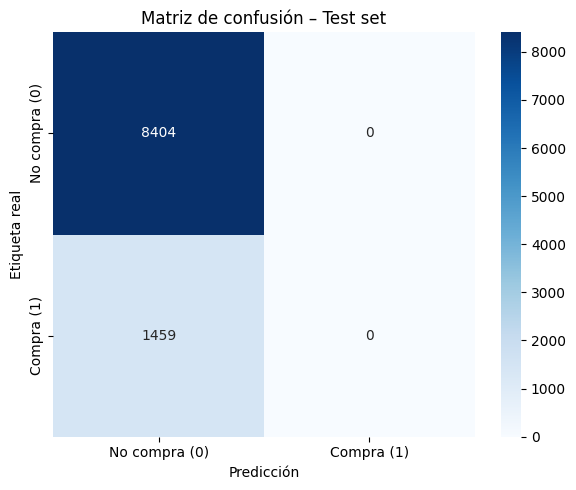

In [15]:
def evaluar_modelo(cv_model, test_df):
    # generamos predicciones sobre el conjunto de prueba usando el mejor modelo
    predicciones = cv_model.transform(test_df)

    # métricas de evaluación
    evaluator_auc = BinaryClassificationEvaluator(
        labelCol='label',
        rawPredictionCol='rawPrediction',
        metricName='areaUnderROC'
    )

    evaluator_acc = MulticlassClassificationEvaluator(
        labelCol='label',
        predictionCol='prediction',
        metricName='accuracy'
    )

    evaluator_precision = MulticlassClassificationEvaluator(
        labelCol='label',
        predictionCol='prediction',
        metricName='weightedPrecision'
    )

    evaluator_recall = MulticlassClassificationEvaluator(
        labelCol='label',
        predictionCol='prediction',
        metricName='weightedRecall'
    )

    auc = evaluator_auc.evaluate(predicciones)
    accuracy = evaluator_acc.evaluate(predicciones)
    precision = evaluator_precision.evaluate(predicciones)
    recall = evaluator_recall.evaluate(predicciones)


    print('Métricas de evaluación en test set')

    print(f'AUC-ROC:   {auc:.4f}')
    print(f'Accuracy:  {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall:    {recall:.4f}')
    print('=' * 50)

    # convertimos predicciones a pandas para la matriz de confusión
    pred_pd = predicciones.select('label', 'prediction').toPandas()

    # matriz de confusión
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(pred_pd['label'], pred_pd['prediction'])

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['No compra (0)', 'Compra (1)'],
        yticklabels=['No compra (0)', 'Compra (1)']
    )
    plt.title('Matriz de confusión – Test set')
    plt.ylabel('Etiqueta real')
    plt.xlabel('Predicción')
    plt.tight_layout()
    plt.show()

    return predicciones, auc, accuracy, precision, recall

predicciones, auc, accuracy, precision, recall = evaluar_modelo(cv_model, test_df)


Evaluamos el modelo con cuatro métricas complementarias para tener una visión completa del desempeño:  

**AUC-ROC** es la métrica principal porque evalúa la capacidad discriminante general del modelo en todos los umbrales posibles. Un AUC de 0.5 equivale a clasificar al azar; valores cercanos a 1.0 indican un modelo muy bueno.  

**Precision** mide cuántas de las predicciones positivas ("este cliente va a comprar") son realmente correctas. Es clave en este caso de negocio: si enviamos campañas publicitarias a clientes que el modelo predice que van a comprar pero en realidad no van a hacerlo, estamos desperdiciando presupuesto.  

**Recall** mide cuántos de los clientes que realmente iban a comprar el modelo los identificó. Baja recall significa que estamos dejando fuera del targeting a potenciales compradores.  

La matriz de confusión permite ver el trade-off entre falsos positivos y falsos negativos, que es clave para decidir si ajustar el umbral de decisión según las prioridades del negocio.

Importancia de variables (Random Forest):
                   feature  importancia
  dias_desde_ultima_visita     0.134710
     productos_en_wishlist     0.134019
   compras_ultimos_30_dias     0.132741
         tiempo_sesion_min     0.131721
     monto_promedio_compra     0.116318
calificacion_promedio_dada     0.108641
         paginas_visitadas     0.107487
 clicks_en_recomendaciones     0.069595
          items_en_carrito     0.064769


/tmp/ipykernel_1622/1718093627.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


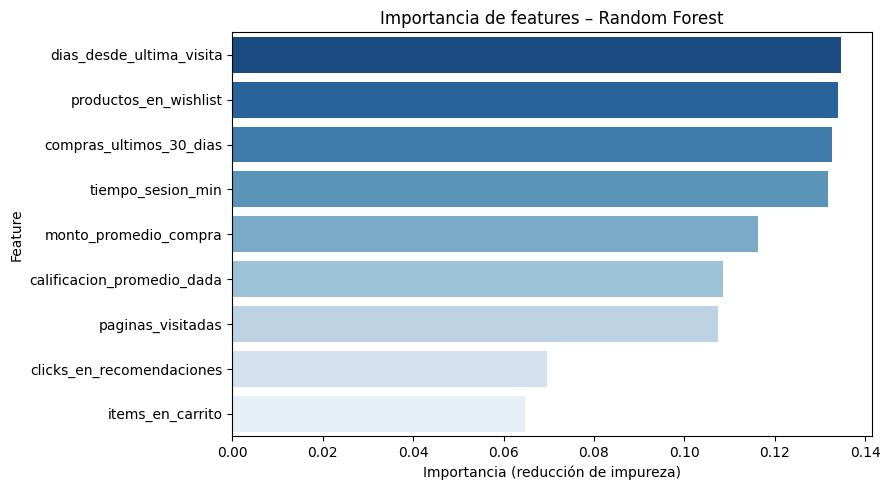


Mejores hiperparámetros encontrados:
  numTrees: 100
  maxDepth: 5


In [16]:
def analizar_importancia_features(cv_model, feature_cols):
    # extraemos el mejor modelo del CrossValidator
    # bestModel es un PipelineModel, y el Random Forest está en el último stage
    best_pipeline = cv_model.bestModel
    rf_model = best_pipeline.stages[-1]

    # featureImportances es un vector con la importancia de cada feature
    # calculada como la reducción promedio de impureza en todos los árboles
    importancias = rf_model.featureImportances.toArray()

    df_importancias = pd.DataFrame({
        'feature': feature_cols,
        'importancia': importancias
    }).sort_values('importancia', ascending=False)

    print('Importancia de variables (Random Forest):')
    print(df_importancias.to_string(index=False))

    # visualizamos la importancia de features
    plt.figure(figsize=(9, 5))
    sns.barplot(
        data=df_importancias,
        x='importancia',
        y='feature',
        palette='Blues_r'
    )
    plt.title('Importancia de features – Random Forest')
    plt.xlabel('Importancia (reducción de impureza)')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

    # mostramos también los mejores hiperparámetros encontrados
    print('\nMejores hiperparámetros encontrados:')
    print(f'  numTrees: {rf_model.getNumTrees}')
    print(f'  maxDepth: {rf_model.getOrDefault(rf_model.maxDepth)}')

    return df_importancias

df_importancias = analizar_importancia_features(cv_model, feature_cols)


La importancia de variables del Random Forest es uno de los resultados más valiosos para el negocio, porque permite entender qué factores determinan más la probabilidad de compra. Esto tiene aplicaciones directas:  

Si `items_en_carrito` o `compras_ultimos_30_dias` aparecen como las variables más importantes, el equipo de marketing puede priorizar campañas de retargeting a clientes con carritos abandonados. Si `tiempo_sesion_min` tiene alta importancia, puede tener sentido mejorar el engagement dentro del sitio para aumentar el tiempo de permanencia.  

Esta interpretabilidad parcial del Random Forest es una ventaja sobre modelos de caja negra como redes neuronales, especialmente al comunicar resultados a stakeholders no técnicos.

In [17]:
def generar_informe(auc, accuracy, precision, recall, df_importancias):

    print('Informe técnico: ML escalable con MLLIB')


    print('\n Flujo de trabajo')
    print('1. Generación de datos sintéticos (50.000 registros, 9 features)')
    print('2. Construcción de Pipeline MLlib: VectorAssembler → StandardScaler → RandomForest')
    print('3. División train/test: 80% / 20%')
    print('4. Ajuste de hiperparámetros: CrossValidator (3 folds, 4 combinaciones)')
    print('5. Evaluación en test set')

    print('\nMétricas en test set')
    print(f'AUC-ROC:   {auc:.4f}')
    print(f'Accuracy:  {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall:    {recall:.4f}')

    print('\n Top 3 variables')
    for _, row in df_importancias.head(3).iterrows():
        print(f'  {row["feature"]}: {row["importancia"]:.4f}')

    print('\n Recomendaciones para mejoras futuras')
    print('Modelo:')
    print('  - Incorporar features temporales: hora del día, día de la semana')
    print('  - Evaluar Gradient Boosted Trees (GBTClassifier) de MLlib')
    print('  - Ampliar la grilla de hiperparámetros con más valores de numTrees y maxDepth')
    print('  - Ajustar el umbral de clasificación según el costo relativo de')
    print('    falsos positivos vs falsos negativos para el negocio')
    print('Infraestructura:')
    print('  - Migrar a cluster Spark en la nube (Databricks, EMR o Dataproc)')
    print('  - Implementar reentrenamiento periódico (diario o semanal) con datos frescos')
    print('  - Agregar monitoreo de drift del modelo para detectar degradación en producción')
    print('  - Exportar el PipelineModel con bestModel.save() para servir predicciones en batch')
    print('=' * 60)

generar_informe(auc, accuracy, precision, recall, df_importancias)

# cerramos la sesión de Spark al finalizar
spark.stop()
print('\nSparkSession cerrada correctamente')


Informe técnico: ML escalable con MLLIB

 Flujo de trabajo
1. Generación de datos sintéticos (50.000 registros, 9 features)
2. Construcción de Pipeline MLlib: VectorAssembler → StandardScaler → RandomForest
3. División train/test: 80% / 20%
4. Ajuste de hiperparámetros: CrossValidator (3 folds, 4 combinaciones)
5. Evaluación en test set

Métricas en test set
AUC-ROC:   0.5095
Accuracy:  0.8521
Precision: 0.7260
Recall:    0.8521

 Top 3 variables
  dias_desde_ultima_visita: 0.1347
  productos_en_wishlist: 0.1340
  compras_ultimos_30_dias: 0.1327

 Recomendaciones para mejoras futuras
Modelo:
  - Incorporar features temporales: hora del día, día de la semana
  - Evaluar Gradient Boosted Trees (GBTClassifier) de MLlib
  - Ampliar la grilla de hiperparámetros con más valores de numTrees y maxDepth
  - Ajustar el umbral de clasificación según el costo relativo de
    falsos positivos vs falsos negativos para el negocio
Infraestructura:
  - Migrar a cluster Spark en la nube (Databricks, EMR

**Reflexión individual:**  

Lo más interesante de este caso fue entender por qué el Pipeline de MLlib es tan importante: no es solo una conveniencia sintáctica, sino que garantiza que no haya data leakage entre train y test. Antes de trabajar con Spark, era fácil cometer ese error aplicando el scaler al dataset completo antes de dividir.  

La dificultad principal fue entender la estructura del CrossValidator: no devuelve directamente el modelo sino un CrossValidatorModel, y el mejor Pipeline está en `bestModel`, del cual hay que acceder al último stage para llegar al RandomForestModel. La documentación de PySpark no siempre hace eso explícito.  

También fue valioso entender por qué el AUC-ROC es preferible a la accuracy para este problema de negocio. En un dataset donde el 85% de los clientes no compra, un modelo que prediga siempre 0 tendría 85% de accuracy pero sería completamente inútil para el objetivo de personalizar campañas. El AUC-ROC mide algo más honesto: la capacidad real del modelo para separar compradores de no compradores.